# Visium visium affine only

Two Visium sections, spots rather than cells: about 250 points each, and their coordinates are array indices spanning roughly 6 to 29 rather than microns. Every length in the solver is in those units, which is why `dx` is 1 and not 30, and why `a` is 5 and not 500 -- the defaults are tuned for micron-scale data and would put the whole section inside a single raster cell.

Upstream's equivalent is `visium-visium-alignment-affine-only`. One call does the alignment: `align_stalign_obs` fits a
diffeomorphism straight between two point clouds, rasterizing both sides itself.

## Inputs

In [1]:
import anndata as ad, numpy as np, pandas as pd

def read_xy(path, x, y, *, skip_first=False):
    """Centroids from a table, as an AnnData carrying only its coordinates."""
    df = pd.read_csv(path)
    xy = np.c_[np.asarray(df[x])[1:] if skip_first else df[x],
               np.asarray(df[y])[1:] if skip_first else df[y]].astype(float)
    return ad.AnnData(X=np.zeros((len(xy), 1)), obsm={'spatial': xy})

def read_headerless(path):
    """Two unnamed columns of coordinates.

    These files carry no header, so a plain `read_csv` promotes the first spot to column names
    and silently drops it. `header=None` keeps every row.
    """
    xy = pd.read_csv(path, header=None).to_numpy(dtype=float)
    return ad.AnnData(X=np.zeros((len(xy), 1)), obsm={'spatial': xy})

def rotated_onto(query, ref, degrees):
    """Upstream's starting guess: rotate about the query's own centroid, then move that
    centroid onto the reference's.

    Applied to the coordinates rather than passed as `initial_affine`, which is what upstream
    does too -- the fit then starts from the identity and the whole initialisation is visible
    here rather than folded into a matrix convention.
    """
    theta = np.deg2rad(-degrees)
    rotation = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
    centred = query.obsm['spatial'] - query.obsm['spatial'].mean(0)
    moved = centred @ rotation.T + ref.obsm['spatial'].mean(0)
    out = query.copy()
    out.obsm['spatial'] = moved
    return out

ref = read_headerless('visium_data/slice2_coor.csv')
query = read_headerless('visium_data/slice1_coor.csv')
print(f'{ref.n_obs} reference cells, {query.n_obs} query cells')

251 reference cells, 254 query cells


## The fit

Upstream's own solver values, and squidpy's defaults for everything else.

In [2]:
from squidpy.experimental.tl import align_stalign_obs

fit = align_stalign_obs(
    ref, query, spatial_key='spatial',
    dx=1.0, blur=1.0, niter=1000, a=5.0, diffeo_start=1001,
)
print(f'{fit.n_iter} iterations, objective '
      f'{float(fit.energies[0]):.0f} -> {float(fit.energies[-1]):.0f}')

/localscratch/selman.ozleyen/stalign-nb-39784580/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


1000 iterations, objective 8 -> 1


## Where the cells land

`transform` evaluates the fitted map at each point, so a cell lands where it lands rather than
at the nearest raster cell.

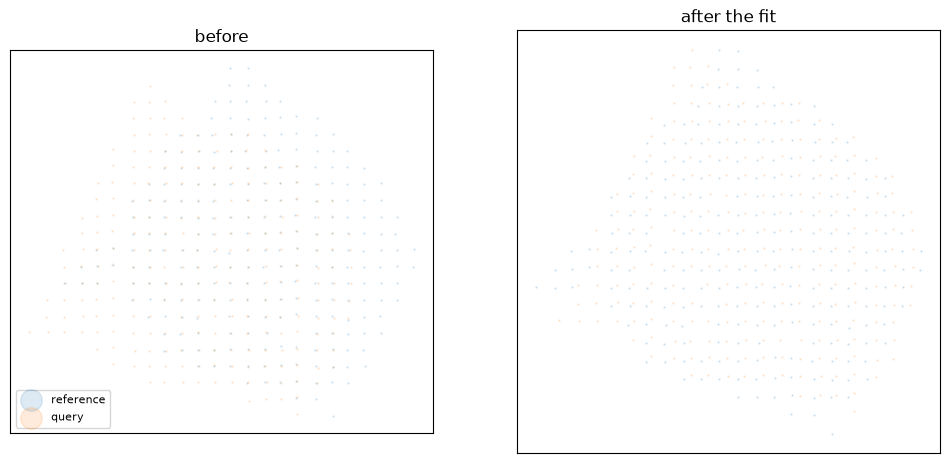

In [3]:
import matplotlib.pyplot as plt

moved = np.asarray(fit.transform(query.obsm['spatial']))
fig, ax = plt.subplots(1, 2, figsize=(12, 5.5))
for a, (pts, title) in zip(ax, [(query.obsm['spatial'], 'before'),
                                (moved, 'after the fit')], strict=True):
    a.scatter(*ref.obsm['spatial'].T, s=0.6, alpha=0.15, label='reference')
    a.scatter(*pts.T, s=0.6, alpha=0.15, label='query')
    a.set_title(title); a.set_aspect('equal'); a.invert_yaxis()
    a.set_xticks([]); a.set_yticks([])
ax[0].legend(markerscale=20, loc='lower left', fontsize=8)

The objective's trace. The mixture E step switches on at iteration 50 and the energy changes
definition there, so only the part after the dashed line is one function.

after the gate: 1 -> 1, minimum 1 at iteration 55
last tenth: mean 1, spread 0 (0.0% of its mean)


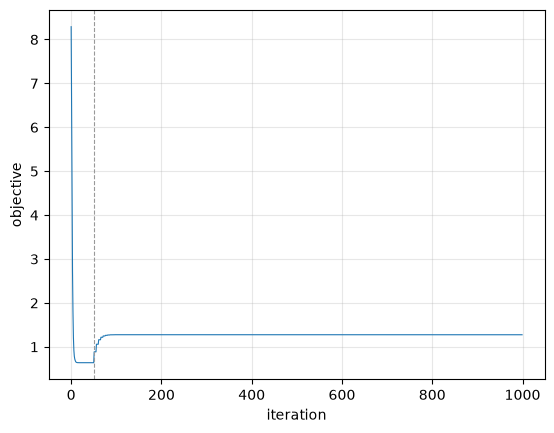

In [4]:
MIXTURE_GATE = 50
energies = np.asarray(fit.energies)[: fit.n_iter]
descent = energies[MIXTURE_GATE + 1 :]
tail = descent[-max(len(descent) // 10, 1) :]
print(f'after the gate: {descent[0]:.0f} -> {descent[-1]:.0f}, minimum {descent.min():.0f} '
      f'at iteration {MIXTURE_GATE + 1 + int(descent.argmin())}')
print(f'last tenth: mean {tail.mean():.0f}, spread {np.ptp(tail):.0f} '
      f'({100 * np.ptp(tail) / tail.mean():.1f}% of its mean)')
plt.plot(energies, lw=0.8); plt.axvline(MIXTURE_GATE, color='0.6', ls='--', lw=0.8)
plt.xlabel('iteration'); plt.ylabel('objective'); plt.grid(alpha=0.3)